In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [52]:
df = pd.read_csv(r"C:\Users\abhis\Downloads\Data_Analytics_Projects\Data Analysis\01_raw_data\OnlineRetail.csv", encoding='ISO-8859-1')

In [53]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
# Remove Missing Values

In [54]:
df = df.dropna(subset=['CustomerID'])

In [6]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [ ]:
# Remove Duplicate Rows

In [15]:
df = df.drop_duplicates()

In [17]:
# Remove Negative Values (Returns)

In [55]:
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [20]:
# Convert Date Format

In [65]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)

In [66]:
# Add Revenue Column

In [67]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [68]:
# Create Total Price

In [69]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  str           
 1   StockCode    397924 non-null  str           
 2   Description  397924 non-null  str           
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[us]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  str           
 8   TotalPrice   397924 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.4 MB


In [70]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,20.34


In [ ]:
# Create RFM Features

In [61]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
# Create RFM table

In [71]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

In [ ]:
# Rename columns

In [74]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
# Handle Outliers

In [77]:
rfm = rfm[(rfm['Monetary'] > 0)]

In [78]:
# Scale Data

In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [ ]:
# Find Optimal Clusters

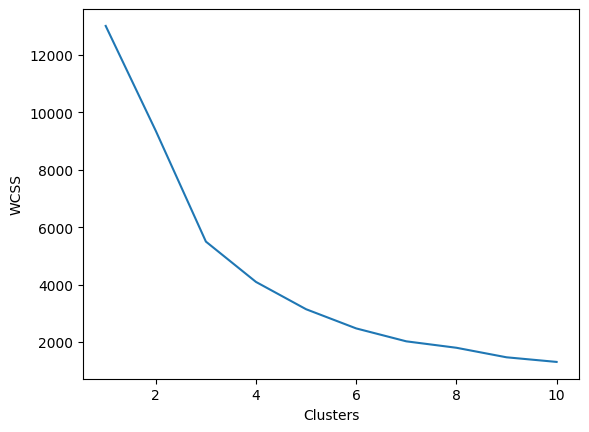

In [80]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

In [81]:
# Apply Clustering (K-Means)

In [82]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [37]:
# Analyze Clusters

In [83]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1359.049284
1,248.075914,1.552015,480.617480
2,7.384615,82.538462,127338.313846
3,15.500000,22.333333,12709.090490


In [ ]:
# Label Clusters

In [85]:
def label(row):
    if row['Monetary'] > 1000:
        return "High Value"
    elif row['Frequency'] > 5:
        return "Loyal"
    else:
        return "Regular"

rfm['Segment'] = rfm.apply(label, axis=1)

In [86]:
# Visualize Clusters

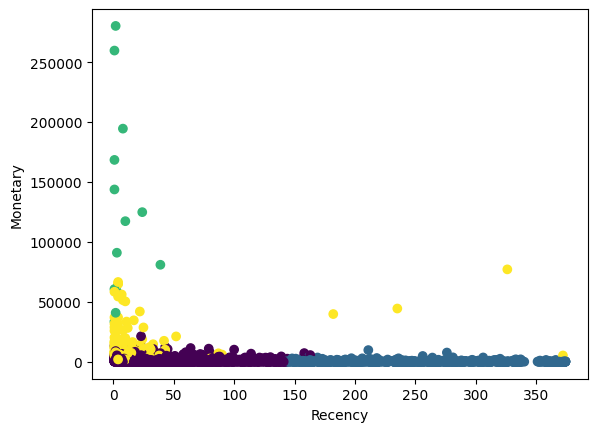

In [87]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

In [88]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,High Value
12347.0,2,7,4310.00,0,High Value
12348.0,75,4,1797.24,0,High Value
12349.0,19,1,1757.55,0,High Value
12350.0,310,1,334.40,1,Regular


In [ ]:
# Convert CustomerID to Integer

In [105]:
rfm = rfm.reset_index()

rfm['CustomerID'] = rfm['CustomerID'].astype(int)

In [ ]:
# Check for Null Values

In [106]:
rfm['CustomerID'].isnull().sum()

np.int64(0)

In [107]:
rfm = rfm.dropna(subset=['CustomerID'])

In [110]:
rfm.to_csv(r"C:\Users\abhis\Downloads\Data_Analytics_Projects\Data Analysis\02_clean_data\customer_segments.csv", index=False)